# 01 — Exploratory Data Analysis

Explore the Kaggle Chest X-Ray Pneumonia dataset (Normal vs Pneumonia).

In [10]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from cxr_pneumonia.config import load_config
from cxr_pneumonia.data import count_split, resolve_split_dir

cfg = load_config(ROOT / "configs" / "default.yaml")
# YAML paths are relative to the project root, not the notebooks/ folder
cfg.data_dir = str((ROOT / cfg.data_dir).resolve())
cfg.artifacts_dir = str((ROOT / cfg.artifacts_dir).resolve())
print("data_dir:", cfg.data_path)

data_dir: /Users/htethtetoo/medical-image-analysis/data/chest_xray


In [11]:
splits = ["train", "val", "test"]
all_counts = {s: count_split(cfg.data_path, s) for s in splits}
all_counts

{'train': {'NORMAL': 1215, 'PNEUMONIA': 3495},
 'val': {'NORMAL': 134, 'PNEUMONIA': 388},
 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}

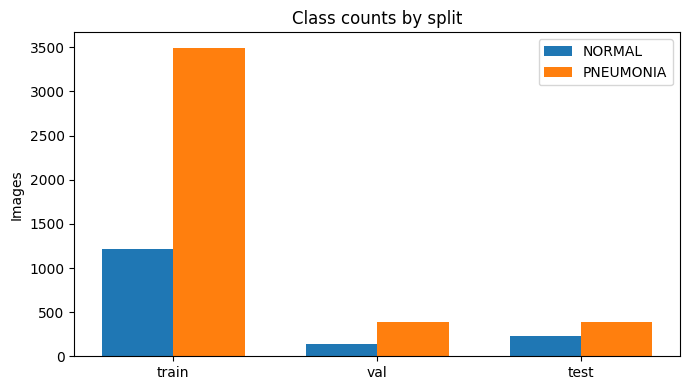

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(splits))
width = 0.35
normals = [all_counts[s].get("NORMAL", 0) for s in splits]
pneus = [all_counts[s].get("PNEUMONIA", 0) for s in splits]
ax.bar(x - width / 2, normals, width, label="NORMAL")
ax.bar(x + width / 2, pneus, width, label="PNEUMONIA")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Images")
ax.set_title("Class counts by split")
ax.legend()
plt.tight_layout()
plt.show()

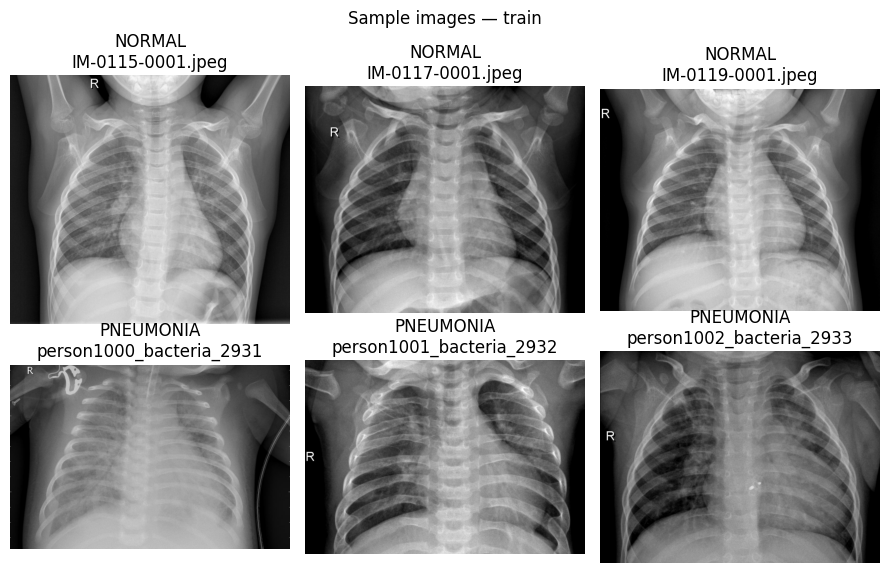

In [13]:
def show_samples(split: str, n_per_class: int = 3):
    split_dir = resolve_split_dir(cfg.data_path, split)
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
    for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
        paths = sorted((split_dir / cls).glob("*.jpeg"))[:n_per_class]
        if not paths:
            paths = sorted((split_dir / cls).glob("*.jpg"))[:n_per_class]
        for col, path in enumerate(paths):
            axes[row, col].imshow(Image.open(path).convert("RGB"))
            axes[row, col].set_title(f"{cls}\n{path.name[:24]}")
            axes[row, col].axis("off")
    fig.suptitle(f"Sample images — {split}")
    plt.tight_layout()
    plt.show()

show_samples("train")

In [14]:
sizes = []
train_dir = resolve_split_dir(cfg.data_path, "train")
for path in list(train_dir.rglob("*.jpeg"))[:200]:
    with Image.open(path) as im:
        sizes.append(im.size)

ws, hs = zip(*sizes) if sizes else ([], [])
print(f"Sampled {len(sizes)} images")
if sizes:
    print(f"width  min/mean/max: {min(ws)} / {np.mean(ws):.0f} / {max(ws)}")
    print(f"height min/mean/max: {min(hs)} / {np.mean(hs):.0f} / {max(hs)}")

Sampled 200 images
width  min/mean/max: 384 / 1197 / 2000
height min/mean/max: 127 / 815 / 1744
